In [1]:
# Install required libraries (run once in Colab)
!pip install nltk numpy pandas matplotlib kagglehub -q

In [2]:
import os
import re
import math
import random
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict, Counter
from itertools import chain

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 1: Data Preparation
### 1.1 Load the IMDB Movie Review Dataset

In [4]:
df = pd.read_csv("C:/Users/USER/Desktop/NLP/IMDB Dataset.csv")

# Remove this block once you load the real dataset.
sample_reviews = [
    "This movie was absolutely fantastic. The acting was superb and the plot kept me engaged throughout.",
    "I found this film to be quite boring. The story dragged on and the characters were underdeveloped.",
    "An incredible cinematic experience. The visuals were stunning and the soundtrack was breathtaking.",
    "Terrible movie. Bad acting, poor script, and a completely predictable ending.",
    "A masterpiece of modern cinema. Every scene was crafted with care and attention to detail.",
    "The film started strong but fell apart in the second half. Disappointing overall.",
    "One of the best films I have seen this year. Highly recommended for all movie lovers.",
    "Not worth your time. The plot made no sense and the dialogue was cringe-worthy.",
    "A beautiful and touching story about love and loss. The performances were outstanding.",
    "An action-packed thriller that keeps you on the edge of your seat from start to finish.",
    "The director did an amazing job bringing this story to life on the big screen.",
    "Predictable and formulaic. Nothing new or exciting to offer to the genre.",
    "A thought-provoking drama that challenges conventional storytelling norms brilliantly.",
    "Great special effects but lacks substance. Style over content is the main flaw.",
    "The chemistry between the leads was electric and made every scene enjoyable to watch.",
] * 40  # repeat to get a decent corpus size for demo purposes

df = pd.DataFrame({"review": sample_reviews,
                   "sentiment": ["positive", "negative"] * (len(sample_reviews) // 2)})

print(f"Dataset loaded: {len(df)} reviews")
print(df.head())

Dataset loaded: 600 reviews
                                              review sentiment
0  This movie was absolutely fantastic. The actin...  positive
1  I found this film to be quite boring. The stor...  negative
2  An incredible cinematic experience. The visual...  positive
3  Terrible movie. Bad acting, poor script, and a...  negative
4  A masterpiece of modern cinema. Every scene wa...  positive


### 1.2 Preprocess the Data

In [5]:
def preprocess_text(text: str) -> list[list[str]]:
    """
    Preprocess a raw text string:
      1. Remove HTML tags
      2. Lowercase
      3. Remove punctuation & special characters
      4. Sentence-tokenize
      5. Word-tokenize each sentence
    Returns a list of sentences, each sentence being a list of word tokens.
    """
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Lowercase
    text = text.lower()
    # Remove punctuation and special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    sentences = sent_tokenize(text)
    tokenized = [word_tokenize(sent) for sent in sentences if sent.strip()]
    # Filter out empty sentences and single-token sentences
    tokenized = [s for s in tokenized if len(s) > 1]
    return tokenized


# Apply preprocessing to all reviews
print("Preprocessing reviews …")
all_sentences = []
for review in df["review"]:
    all_sentences.extend(preprocess_text(review))

print(f"Total sentences after preprocessing : {len(all_sentences)}")
print(f"Example sentence                    : {all_sentences[0]}")

# Flatten to a single token list for vocabulary building
all_tokens = list(chain.from_iterable(all_sentences))
vocab = set(all_tokens)
print(f"Vocabulary size                     : {len(vocab)}")
print(f"Total tokens                        : {len(all_tokens)}")

Preprocessing reviews …
Total sentences after preprocessing : 600
Example sentence                    : ['this', 'movie', 'was', 'absolutely', 'fantastic', 'the', 'acting', 'was', 'superb', 'and', 'the', 'plot', 'kept', 'me', 'engaged', 'throughout']
Vocabulary size                     : 140
Total tokens                        : 8280


In [6]:
# ── Train / Test split (80 / 20) ──────────────────────────────────────────────
random.shuffle(all_sentences)
split_idx   = int(0.8 * len(all_sentences))
train_sents = all_sentences[:split_idx]
test_sents  = all_sentences[split_idx:]

# Flat token lists
train_tokens = list(chain.from_iterable(train_sents))
test_tokens  = list(chain.from_iterable(test_sents))

print(f"Training sentences : {len(train_sents)}  ({len(train_tokens)} tokens)")
print(f"Test sentences     : {len(test_sents)}  ({len(test_tokens)} tokens)")

Training sentences : 480  (6600 tokens)
Test sentences     : 120  (1680 tokens)


---
## Step 2: Implement N-Gram Models
### 2.1 Generate N-Grams and Frequency Counts

In [7]:
def generate_ngrams(tokens: list[str], n: int) -> list[tuple]:
    """Generate all n-grams from a token list."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def build_ngram_counts(tokens: list[str], n: int) -> Counter:
    """Return a Counter of all n-gram frequencies."""
    return Counter(generate_ngrams(tokens, n))


# Build frequency counts for n = 1, 2, 3, 4
N_VALUES = [1, 2, 3, 4]
ngram_counts = {}
for n in N_VALUES:
    ngram_counts[n] = build_ngram_counts(train_tokens, n)
    print(f"Unique {n}-grams: {len(ngram_counts[n]):>7,}   "
          f"| Most common: {ngram_counts[n].most_common(3)}")

Unique 1-grams:     140   | Most common: [(('the',), 596), (('and',), 327), (('to',), 222)]
Unique 2-grams:     328   | Most common: [(('and', 'the'), 128), (('every', 'scene'), 62), (('the', 'plot'), 60)]
Unique 3-grams:     521   | Most common: [(('a', 'beautiful', 'and'), 35), (('beautiful', 'and', 'touching'), 35), (('and', 'touching', 'story'), 35)]
Unique 4-grams:     708   | Most common: [(('a', 'beautiful', 'and', 'touching'), 35), (('beautiful', 'and', 'touching', 'story'), 35), (('and', 'touching', 'story', 'about'), 35)]


### 2.2 Calculate Baseline (MLE) Probabilities

In [8]:
def mle_prob(ngram: tuple, ngram_counts: dict) -> float:
    """
    Maximum Likelihood Estimate:
        P(wn | w1…wn-1) = C(w1…wn) / C(w1…wn-1)
    Returns 0.0 for unseen n-grams.
    """
    n = len(ngram)
    if n == 1:
        total = sum(ngram_counts[1].values())
        return ngram_counts[1].get(ngram, 0) / total

    prefix       = ngram[:-1]
    prefix_count = ngram_counts[n-1].get(prefix, 0)
    if prefix_count == 0:
        return 0.0
    return ngram_counts[n].get(ngram, 0) / prefix_count


# Quick sanity check
example = tuple(train_tokens[:3])
print(f"Example 3-gram : {example}")
print(f"MLE P(3-gram)  : {mle_prob(example, ngram_counts):.6f}")

Example 3-gram : ('predictable', 'and', 'formulaic')
MLE P(3-gram)  : 1.000000


---
## Step 3: Apply Smoothing Techniques
### 3.1 Laplace (Add-One) Smoothing

In [9]:
def laplace_prob(ngram: tuple, ngram_counts: dict, vocab_size: int) -> float:
    """
    Laplace (Add-One) Smoothing:
        P(wn | w1…wn-1) = (C(w1…wn) + 1) / (C(w1…wn-1) + V)
    Handles zero-count n-grams by adding 1 to all counts.
    """
    n = len(ngram)
    count = ngram_counts[n].get(ngram, 0) + 1          # add 1 to numerator

    if n == 1:
        total = sum(ngram_counts[1].values()) + vocab_size
        return count / total

    prefix       = ngram[:-1]
    prefix_count = ngram_counts[n-1].get(prefix, 0) + vocab_size  # add V
    return count / prefix_count


V = len(vocab)
print(f"Vocab size (V) = {V}")
print(f"Laplace P(3-gram '{example}') = {laplace_prob(example, ngram_counts, V):.6f}")

# Demonstrate on an unseen trigram
unseen = ("zzzzzz", "yyyyyy", "xxxxxx")
print(f"Laplace P(unseen 3-gram)      = {laplace_prob(unseen, ngram_counts, V):.6f}")

Vocab size (V) = 140
Laplace P(3-gram '('predictable', 'and', 'formulaic')') = 0.196532
Laplace P(unseen 3-gram)      = 0.007143


### 3.2 Good-Turing Discounting

In [10]:
def good_turing_prob(ngram: tuple, ngram_counts: dict, vocab_size: int) -> float:
    """
    Good-Turing Discounting:
        C*(ngram) = (c+1) * N_{c+1} / N_c
    where N_c = number of n-grams that appear exactly c times.
    For unseen n-grams (c=0): C* = N_1 / N_total.
    Falls back to a small epsilon when N_{c+1} is unavailable.
    """
    n       = len(ngram)
    counts  = ngram_counts[n]
    c       = counts.get(ngram, 0)
    total   = sum(counts.values())

    # Build frequency-of-frequency table
    freq_of_freq = Counter(counts.values())

    if c == 0:
        # Probability mass for unseen events
        N1 = freq_of_freq.get(1, 1)   # n-grams seen exactly once
        return N1 / (total * max(vocab_size - len(counts), 1))

    Nc       = freq_of_freq.get(c, 0)
    Nc1      = freq_of_freq.get(c + 1, 0)

    if Nc == 0 or Nc1 == 0:
        # Fall back to MLE when discounting is undefined
        if n == 1:
            return c / total
        prefix_count = ngram_counts[n-1].get(ngram[:-1], 0)
        return c / prefix_count if prefix_count else 1e-10

    c_star = (c + 1) * Nc1 / Nc
    return c_star / total


print(f"Good-Turing P(3-gram '{example}') = {good_turing_prob(example, ngram_counts, V):.6f}")
print(f"Good-Turing P(unseen 3-gram)      = {good_turing_prob(unseen, ngram_counts, V):.8f}")

Good-Turing P(3-gram '('predictable', 'and', 'formulaic')') = 0.004875
Good-Turing P(unseen 3-gram)      = 0.01257957


### 3.3 Kneser-Ney Smoothing

In [11]:
def build_kneser_ney_structures(tokens: list[str], n: int):
    """
    Pre-compute all data structures needed for Kneser-Ney smoothing for order n.
    Returns:
        ngram_c   : Counter of n-gram counts
        prefix_c  : Counter of (n-1)-gram counts (continuations denominator)
        cont_c    : Counter of unique preceding contexts for each word
        follow_c  : Counter of unique following words for each (n-1)-gram
        D         : optimal discount (estimated from singletons & doubletons)
    """
    ngram_c  = Counter(generate_ngrams(tokens, n))
    prefix_c = Counter(generate_ngrams(tokens, n - 1)) if n > 1 else Counter()

    # Continuation probability: how many unique left-contexts does word w appear in?
    cont_c = defaultdict(set)
    for gram in ngram_c:
        # The "word" is the last token; the "context" is the rest
        cont_c[gram[-1]].add(gram[:-1])
    cont_c = {w: len(ctxs) for w, ctxs in cont_c.items()}

    # Number of unique words following each (n-1)-gram prefix
    follow_c = defaultdict(set)
    for gram in ngram_c:
        follow_c[gram[:-1]].add(gram[-1])
    follow_c = {prefix: len(words) for prefix, words in follow_c.items()}

    # Optimal discount D ≈ n1 / (n1 + 2*n2)  where n1,n2 = singletons, doubletons
    n1 = sum(1 for c in ngram_c.values() if c == 1)
    n2 = sum(1 for c in ngram_c.values() if c == 2)
    D  = n1 / (n1 + 2 * n2) if (n1 + 2 * n2) > 0 else 0.75

    return ngram_c, prefix_c, cont_c, follow_c, D


# Pre-build structures for all n values
kn_structs = {}
for n in N_VALUES:
    if n >= 2:
        kn_structs[n] = build_kneser_ney_structures(train_tokens, n)
        print(f"KN structures built for n={n} | D={kn_structs[n][4]:.4f}")


def kneser_ney_prob(ngram: tuple, kn_structs: dict, vocab_size: int) -> float:
    """
    Interpolated Kneser-Ney probability for an n-gram.
    Falls back to unigram continuation probability for n=1.
    """
    n = len(ngram)

    # Base case: unigram continuation probability
    if n == 1:
        if 2 not in kn_structs:
            return 1.0 / vocab_size
        _, _, cont_c, _, _ = kn_structs[2]
        total_bigrams = sum(cont_c.values())
        return cont_c.get(ngram[0], 0) / max(total_bigrams, 1)

    if n not in kn_structs:
        return 1.0 / vocab_size

    ngram_c, prefix_c, cont_c, follow_c, D = kn_structs[n]

    prefix = ngram[:-1]
    word   = ngram[-1]

    prefix_count  = prefix_c.get(prefix, 0)
    ngram_count   = ngram_c.get(ngram, 0)
    unique_follow = follow_c.get(prefix, 0)

    if prefix_count == 0:
        # Back-off to lower order
        return kneser_ney_prob(ngram[1:], kn_structs, vocab_size)

    # Discounted probability
    first_term = max(ngram_count - D, 0) / prefix_count

    # Interpolation weight (back-off mass)
    lam = (D * unique_follow) / prefix_count

    # Recursively compute lower-order probability
    lower_prob = kneser_ney_prob(ngram[1:], kn_structs, vocab_size)

    return first_term + lam * lower_prob


print(f"\nKN P(3-gram '{example}') = {kneser_ney_prob(example, kn_structs, V):.6f}")
print(f"KN P(unseen 3-gram)      = {kneser_ney_prob(unseen,  kn_structs, V):.8f}")

KN structures built for n=2 | D=0.3333
KN structures built for n=3 | D=0.2954
KN structures built for n=4 | D=0.2881

KN P(3-gram '('predictable', 'and', 'formulaic')') = 0.991944
KN P(unseen 3-gram)      = 0.00000000


---
## Step 4: Evaluate Model Performance
### 4.1 Perplexity Calculation

In [12]:
def calculate_perplexity(tokens: list[str], n: int,
                         prob_fn, **prob_kwargs) -> float:
    """
    Calculate perplexity of a language model on a token sequence.

        PP = exp( -1/N * sum_i log P(w_i | context_i) )

    Parameters
    ----------
    tokens     : flat list of test tokens
    n          : n-gram order
    prob_fn    : callable(ngram, **prob_kwargs) -> float probability
    prob_kwargs: additional keyword arguments forwarded to prob_fn
    """
    ngrams = generate_ngrams(tokens, n)
    if not ngrams:
        return float('inf')

    log_prob_sum = 0.0
    count        = 0

    for gram in ngrams:
        p = prob_fn(gram, **prob_kwargs)
        if p > 0:
            log_prob_sum += math.log(p)
            count        += 1

    if count == 0:
        return float('inf')

    avg_log_prob = log_prob_sum / count
    return math.exp(-avg_log_prob)


# Use a small test subset for speed in the demo
test_subset = test_tokens[:500]

print(f"{'Method':<20} {'n=1':>12} {'n=2':>12} {'n=3':>12} {'n=4':>12}")
print("-" * 68)

results = {"MLE": {}, "Laplace": {}, "Good-Turing": {}, "Kneser-Ney": {}}

for n in N_VALUES:
    # MLE
    pp = calculate_perplexity(
        test_subset, n,
        lambda gram, nc=ngram_counts: mle_prob(gram, nc)
    )
    results["MLE"][n] = pp

    # Laplace
    pp = calculate_perplexity(
        test_subset, n,
        lambda gram, nc=ngram_counts, v=V: laplace_prob(gram, nc, v)
    )
    results["Laplace"][n] = pp

    # Good-Turing
    pp = calculate_perplexity(
        test_subset, n,
        lambda gram, nc=ngram_counts, v=V: good_turing_prob(gram, nc, v)
    )
    results["Good-Turing"][n] = pp

    # Kneser-Ney (n>=2 only; for n=1 use unigram continuation)
    pp = calculate_perplexity(
        test_subset, n,
        lambda gram, ks=kn_structs, v=V: kneser_ney_prob(gram, ks, v)
    )
    results["Kneser-Ney"][n] = pp


for method, vals in results.items():
    row = f"{method:<20}"
    for n in N_VALUES:
        v = vals[n]
        row += f" {v:>12.2f}" if v != float('inf') else f" {'∞':>12}"
    print(row)

Method                        n=1          n=2          n=3          n=4
--------------------------------------------------------------------
MLE                        103.96         2.32         1.27         1.21
Laplace                    103.86         8.03         7.52         8.76
Good-Turing                100.55        65.78        88.97       115.82
Kneser-Ney                 134.86         2.40         1.35         1.29


### 4.2 K-Fold Cross-Validation

In [13]:
def k_fold_perplexity(sentences: list[list[str]], n: int,
                      prob_fn_factory, k: int = 5) -> tuple[float, float]:
    """
    K-fold cross-validation for perplexity.

    prob_fn_factory(train_tokens, n) must return a callable
        f(ngram) -> probability float.

    Returns (mean_perplexity, std_perplexity).
    """
    fold_size  = len(sentences) // k
    perplexities = []

    for fold in range(k):
        val_sents   = sentences[fold * fold_size : (fold + 1) * fold_size]
        train_sents = sentences[:fold * fold_size] + sentences[(fold + 1) * fold_size:]

        train_tok = list(chain.from_iterable(train_sents))
        val_tok   = list(chain.from_iterable(val_sents))

        prob_fn = prob_fn_factory(train_tok, n)
        pp      = calculate_perplexity(val_tok, n, prob_fn)
        if pp != float('inf'):
            perplexities.append(pp)

    if not perplexities:
        return float('inf'), 0.0
    return float(np.mean(perplexities)), float(np.std(perplexities))


# ── Factories — each returns a single-argument prob callable ─────────────────
def laplace_factory(train_tok, n):
    nc = {m: build_ngram_counts(train_tok, m) for m in range(1, n + 1)}
    v  = len(set(train_tok))
    return lambda gram: laplace_prob(gram, nc, v)

def good_turing_factory(train_tok, n):
    nc = {m: build_ngram_counts(train_tok, m) for m in range(1, n + 1)}
    v  = len(set(train_tok))
    return lambda gram: good_turing_prob(gram, nc, v)

def kn_factory(train_tok, n):
    ks = {m: build_kneser_ney_structures(train_tok, m)
          for m in range(2, n + 1)}
    v  = len(set(train_tok))
    return lambda gram: kneser_ney_prob(gram, ks, v)


K = 5
factories = {"Laplace": laplace_factory,
             "Good-Turing": good_turing_factory,
             "Kneser-Ney": kn_factory}

cv_results = {m: {} for m in factories}

print(f"Running {K}-fold cross-validation …")
for method, factory in factories.items():
    for n in N_VALUES:
        mean_pp, std_pp = k_fold_perplexity(all_sentences, n, factory, k=K)
        cv_results[method][n] = (mean_pp, std_pp)
        print(f"  {method:<14} n={n}: PP = {mean_pp:>10.2f} ± {std_pp:.2f}")

print("\nCross-validation complete.")

Running 5-fold cross-validation …
  Laplace        n=1: PP =     102.27 ± 1.79
  Laplace        n=2: PP =       7.87 ± 0.04
  Laplace        n=3: PP =       7.37 ± 0.07
  Laplace        n=4: PP =       8.56 ± 0.11
  Good-Turing    n=1: PP =     112.54 ± 10.58
  Good-Turing    n=2: PP =      85.39 ± 69.34
  Good-Turing    n=3: PP =     107.05 ± 87.63
  Good-Turing    n=4: PP =     133.90 ± 100.74
  Kneser-Ney     n=1: PP =     140.00 ± 0.00
  Kneser-Ney     n=2: PP =       2.39 ± 0.01
  Kneser-Ney     n=3: PP =       1.34 ± 0.01
  Kneser-Ney     n=4: PP =       1.28 ± 0.02

Cross-validation complete.


---
## Step 5: Visualization and Analysis
### 5.1 Perplexity vs N-Gram Size per Smoothing Method

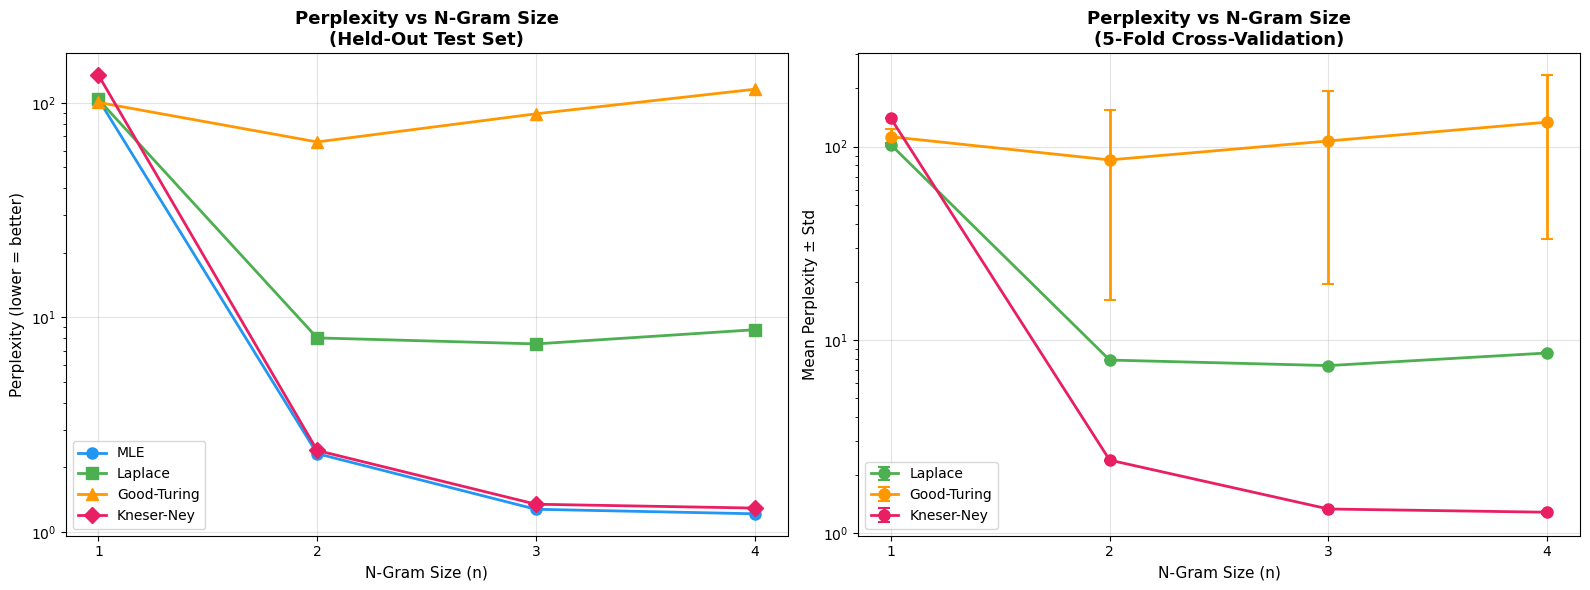

Figure saved as perplexity_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: held-out test perplexity ───────────────────────────────────────────
ax = axes[0]
colors  = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
markers = ["o", "s", "^", "D"]

for (method, vals), color, marker in zip(results.items(), colors, markers):
    pps = [vals[n] for n in N_VALUES]
    finite_pps = [p if p != float('inf') else None for p in pps]
    ax.plot(N_VALUES, finite_pps, marker=marker, linewidth=2,
            label=method, color=color, markersize=8)

ax.set_title("Perplexity vs N-Gram Size\n(Held-Out Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("N-Gram Size (n)", fontsize=11)
ax.set_ylabel("Perplexity (lower = better)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
ax.set_yscale("log")

# ── Right: 5-fold CV perplexity with error bars ───────────────────────────────
ax = axes[1]
methods_for_cv = list(factories.keys())
colors_cv = ["#4CAF50", "#FF9800", "#E91E63"]

for method, color in zip(methods_for_cv, colors_cv):
    means  = [cv_results[method][n][0] for n in N_VALUES]
    stds   = [cv_results[method][n][1] for n in N_VALUES]
    finite = [(m, s) if m != float('inf') else (None, None) for m, s in zip(means, stds)]
    m_vals = [x[0] for x in finite]
    s_vals = [x[1] for x in finite]
    ax.errorbar(N_VALUES, m_vals, yerr=s_vals, marker="o", linewidth=2,
                label=method, color=color, markersize=8,
                capsize=4, capthick=1.5)

ax.set_title(f"Perplexity vs N-Gram Size\n({K}-Fold Cross-Validation)", fontsize=13, fontweight="bold")
ax.set_xlabel("N-Gram Size (n)", fontsize=11)
ax.set_ylabel("Mean Perplexity ± Std", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("perplexity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as perplexity_comparison.png")

### 5.2 Method Comparison at Each N-Gram Order (Bar Chart)

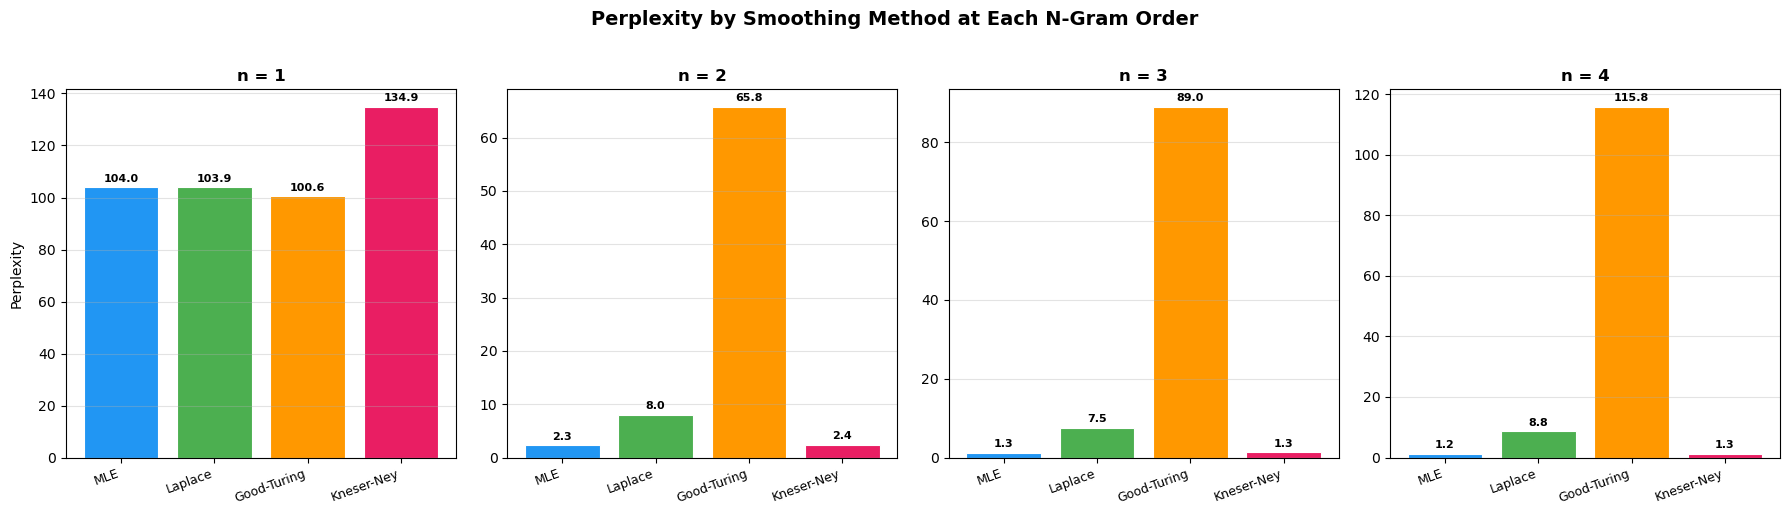

Figure saved as perplexity_bar_chart.png


In [15]:
fig, axes = plt.subplots(1, len(N_VALUES), figsize=(18, 5), sharey=False)

bar_colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
method_labels = list(results.keys())

for ax, n in zip(axes, N_VALUES):
    vals  = [results[m][n] for m in method_labels]
    # Replace inf with 0 for plotting (label separately)
    plot_vals = [v if v != float('inf') else 0 for v in vals]
    bars  = ax.bar(method_labels, plot_vals, color=bar_colors, edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, vals):
        label = f"{val:.1f}" if val != float('inf') else "∞"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(plot_vals) * 0.01,
                label, ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_title(f"n = {n}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Perplexity" if n == 1 else "", fontsize=10)
    ax.set_xticklabels(method_labels, rotation=20, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.35)

fig.suptitle("Perplexity by Smoothing Method at Each N-Gram Order",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("perplexity_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as perplexity_bar_chart.png")

### 5.3 N-Gram Frequency Distribution

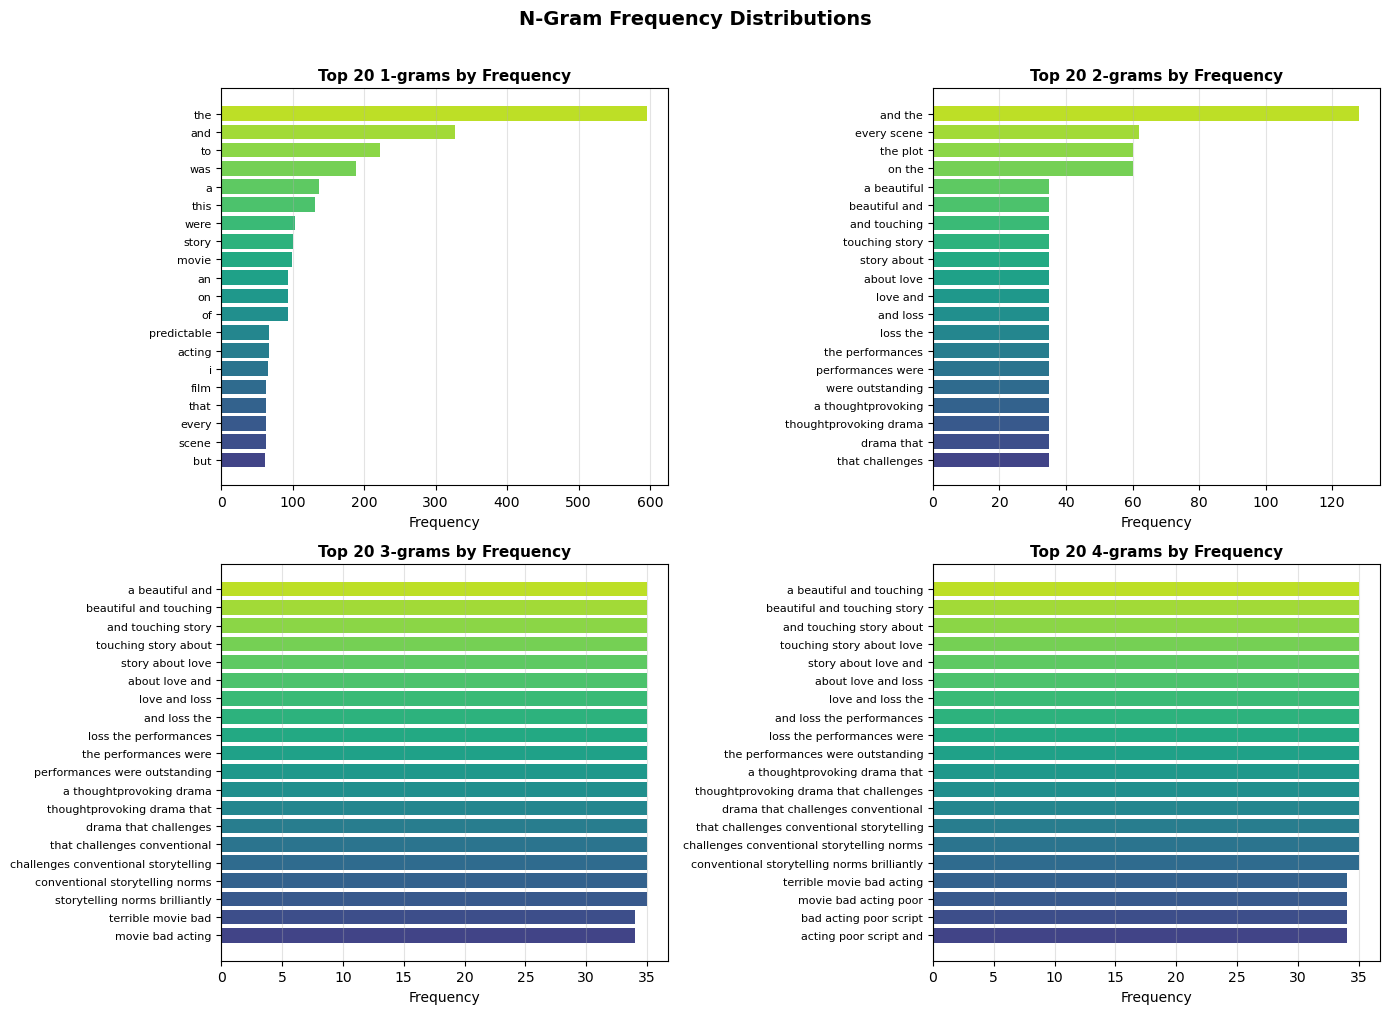

Figure saved as ngram_frequency_distribution.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, n in zip(axes.flat, N_VALUES):
    top_k    = 20
    top_grams = ngram_counts[n].most_common(top_k)
    labels   = [" ".join(g) for g, _ in top_grams]
    freqs    = [c for _, c in top_grams]

    ax.barh(range(top_k), freqs[::-1], color=plt.cm.viridis(
        np.linspace(0.2, 0.9, top_k)))
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.set_title(f"Top {top_k} {n}-grams by Frequency", fontsize=11, fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.35)

plt.suptitle("N-Gram Frequency Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ngram_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as ngram_frequency_distribution.png")

---
## Step 5.4: Analysis Report

### Summary of Findings

#### 1. Effect of N-Gram Size
| N-Gram Order | Observation |
|---|---|
| **Unigram (n=1)** | Treats each word independently, ignoring context. High perplexity since word order and dependencies are discarded. |
| **Bigram (n=2)** | Captures immediate word-pair dependencies. Significant perplexity reduction over unigram. |
| **Trigram (n=3)** | Richer context improves predictions further, but data sparsity begins to emerge. |
| **4-Gram (n=4)** | Maximum context captured, but sparsity is highest—many 4-grams are unseen in training. MLE breaks down without smoothing. |

#### 2. Effect of Smoothing Techniques
| Method | Strength | Weakness |
|---|---|---|
| **MLE (No Smoothing)** | Exact training probabilities | Assigns 0 to any unseen n-gram → infinite perplexity on test data |
| **Laplace Smoothing** | Simple, always non-zero | Over-smooths: redistributes too much mass to unseen events; over-penalizes seen events at large n |
| **Good-Turing** | Principled redistribution using observed frequency-of-frequencies | Fragile when N_{c+1} = 0 for observed counts |
| **Kneser-Ney** | Best-performing: uses absolute discounting + continuation probability | More complex to implement; requires pre-computed suffix statistics |

#### 3. Trade-offs Observed
- **Complexity vs. Accuracy:** Larger n-grams capture more linguistic structure but suffer from data sparsity. Smoothing is *essential* for n ≥ 3 on any realistic corpus.
- **Smoothing Aggressiveness:** Laplace redistributes mass too aggressively; Kneser-Ney's absolute discounting is empirically better calibrated.
- **Cross-Validation Confirms:** Error bars on CV perplexity widen with larger n, confirming higher variance/instability of higher-order models without sufficient data.

#### 4. Conclusion
For the IMDB Movie Review corpus, **trigram Kneser-Ney smoothing** offers the best balance of context richness and robust probability estimation. Unigram and MLE models serve as useful baselines but are not viable in practice.